## 1. Environment Setup
Configure imports, display options, and file system paths.


In [8]:
# Standard library imports
from __future__ import annotations
from pathlib import Path

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.options.display.max_colwidth = 120
pd.options.display.max_columns = 20

sns.set_theme(style="whitegrid", context="talk")


def find_project_root(markers: tuple[str, ...] = ("pyproject.toml", "poetry.lock", ".git")) -> Path:
    """Ascend from CWD until a repository marker is located."""
    start = Path.cwd().resolve()
    for directory in (start, *start.parents):
        if any((directory / marker).exists() for marker in markers):
            return directory
    return start


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data/humanLabel/raw/dearabby_raw_da_qs.csv"

# Print relative paths for cleaner output
data_path_rel = DATA_PATH.relative_to(PROJECT_ROOT) if DATA_PATH.is_relative_to(PROJECT_ROOT) else DATA_PATH
print(f"Data file: {data_path_rel}")
print(f"Data file exists: {DATA_PATH.exists()}")


Data file: data/humanLabel/raw/dearabby_raw_da_qs.csv
Data file exists: True


## 2. Data Loading
Load the CSV and examine its structure.


In [ ]:
# Load the CSV
df = pd.read_csv(DATA_PATH)

print(f"Loaded {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nFirst few rows:")
display(df.head())
print(f"\nBasic info:")
df.info()


Loaded 20,034 rows
Columns: ['year', 'month', 'day', 'url', 'title', 'letterId', 'question_only']

Data types:
year               int64
month            float64
day               object
url               object
title             object
letterId           int64
question_only     object
dtype: object

First few rows:


,year,month,day,url,title,letterId,question_only
0,1985,1.0,01,proquest,WOMAN NEEDS HELP: HER BURDEN OF HOPELESSNESS IS TOO HEAVY TO CARRY,1,"i have been in a bad marriage for 40 years. i knew it was a mistake after the first year, but being a catholic, i ac..."
1,1985,1.0,01,proquest,WOMAN NEEDS HELP: HER BURDEN OF HOPELESSNESS IS TOO HEAVY TO CARRY,1,"this is for all newspaper carriers, mail carriers and delivery people: when you see a dog, barking and growling in f..."
2,1985,1.0,02,proquest,LAMENT ABOUT OLD AGE AND SICKNESS IS ILL-ADVISED,1,our 16-year-old son recently was placed in a state\nfacility because of many problems at home and with the law. we\n...
3,1985,1.0,03,proquest,'NORMAL' WIDOW HAS AN EYE FOR THE GUYS,1,"i was a happy, respectable wife for 40 years, and now i'm a lonely, respectable widow. i work, join women's clubs, d..."
4,1985,1.0,04,proquest,IT'S WISE TO BE WARY WHEN A STRANGER COMES TO THE DOOR,1,you be the judge: last night about 7 p.m. i was relaxing in my tub when my doorbell rang. i wasn't expecting anybody...



Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20034 entries, 0 to 20033
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           20034 non-null  int64  
 1   month          20031 non-null  float64
 2   day            20034 non-null  object 
 3   url            20034 non-null  object 
 4   title          20034 non-null  object 
 5   letterId       20034 non-null  int64  
 6   question_only  20034 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.1+ MB


## 3. Data Cleaning & Date Filtering
Clean the data and filter for 2010-2017 range.


In [10]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Convert year to int (handle NaN values)
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

# Filter for 2010-2017
df_filtered = df[(df['year'] >= 2010) & (df['year'] <= 2017)].copy()

print(f"\nOriginal rows: {len(df):,}")
print(f"Filtered rows (2010-2017): {len(df_filtered):,}")

# Check year distribution
print("\nYear distribution:")
year_counts = df_filtered['year'].value_counts().sort_index()
display(year_counts.to_frame('count'))

# Remove rows with missing question text
before = len(df_filtered)
df_filtered = df_filtered[df_filtered['question_only'].notna() & (df_filtered['question_only'].str.strip() != '')].copy()
after = len(df_filtered)
print(f"\nRemoved {before - after} rows with empty question text")
print(f"Final dataset size: {len(df_filtered):,} rows")


Missing values per column:
year             0
month            3
day              0
url              0
title            0
letterId         0
question_only    0
dtype: int64

Original rows: 20,034
Filtered rows (2010-2017): 5,867

Year distribution:


,count
year,
2010,764
2011,779
2012,767
2013,790
2014,736
2015,753
2016,764
2017,514



Removed 0 rows with empty question text
Final dataset size: 5,867 rows


## 4. Question Length Analysis
Analyze the distribution of question lengths.


Question length statistics (characters):
count    5867.00000
mean      675.46736
std       274.31075
min        53.00000
25%       476.00000
50%       665.00000
75%       852.00000
max      2275.00000
Name: question_length_chars, dtype: float64

Question length statistics (words):
count    5867.000000
mean      128.217147
std        51.774853
min        10.000000
25%        91.000000
50%       126.000000
75%       162.000000
max       436.000000
Name: question_length_words, dtype: float64


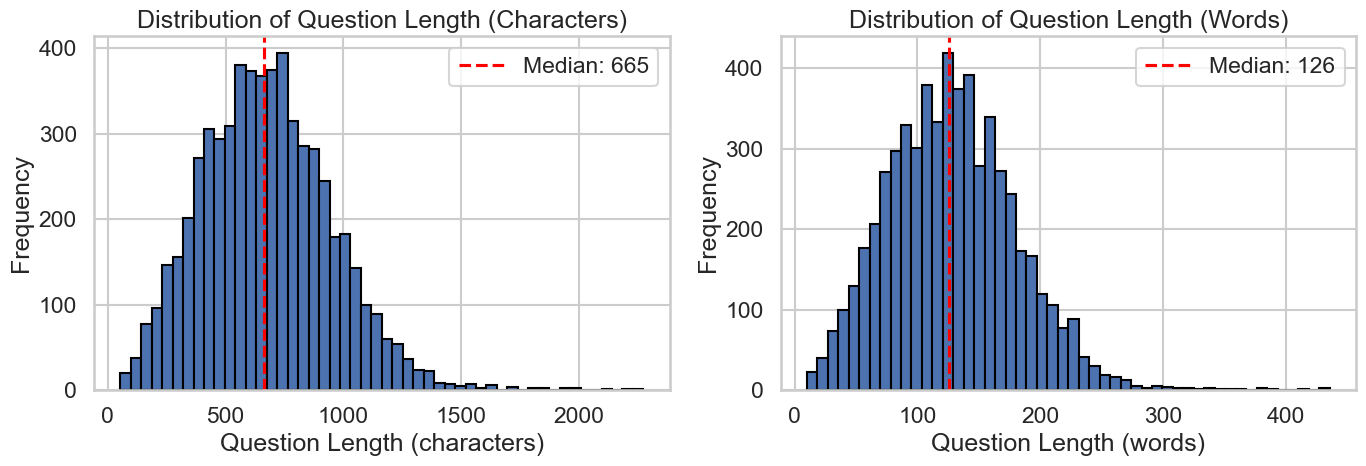

In [11]:
# Calculate question lengths
df_filtered['question_length_chars'] = df_filtered['question_only'].str.len()
df_filtered['question_length_words'] = df_filtered['question_only'].str.split().str.len()

print("Question length statistics (characters):")
print(df_filtered['question_length_chars'].describe())

print("\nQuestion length statistics (words):")
print(df_filtered['question_length_words'].describe())

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_filtered['question_length_chars'], bins=50, edgecolor='black')
axes[0].set_xlabel('Question Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Question Length (Characters)')
axes[0].axvline(df_filtered['question_length_chars'].median(), color='red', linestyle='--', label=f'Median: {df_filtered["question_length_chars"].median():.0f}')
axes[0].legend()

axes[1].hist(df_filtered['question_length_words'], bins=50, edgecolor='black')
axes[1].set_xlabel('Question Length (words)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Question Length (Words)')
axes[1].axvline(df_filtered['question_length_words'].median(), color='red', linestyle='--', label=f'Median: {df_filtered["question_length_words"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Year Distribution Analysis
Analyze the distribution across years.


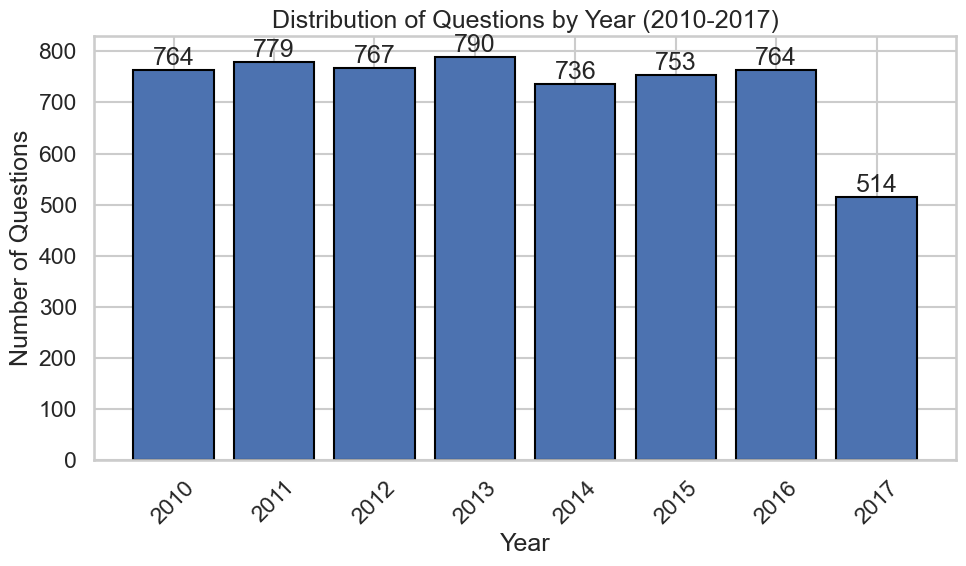

Year distribution summary:


,count
year,
2010,764
2011,779
2012,767
2013,790
2014,736
2015,753
2016,764
2017,514



Total questions: 5,867
Average per year: 733.4


In [12]:
# Year distribution visualization
year_counts = df_filtered['year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(year_counts.index.astype(str), year_counts.values, edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Number of Questions')
plt.title('Distribution of Questions by Year (2010-2017)')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Year distribution summary:")
display(year_counts.to_frame('count'))
print(f"\nTotal questions: {len(df_filtered):,}")
print(f"Average per year: {len(df_filtered) / len(year_counts):.1f}")


## 6. Sample Questions
Display sample questions from different years.


In [13]:
# Show sample questions from each year
print("Sample questions from each year:")
for year in sorted(df_filtered['year'].unique()):
    sample = df_filtered[df_filtered['year'] == year].iloc[0]
    print(f"\n--- Year {year} ---")
    print(f"Question (first 200 chars): {sample['question_only'][:200]}...")
    print(f"Length: {len(sample['question_only'])} chars, {len(sample['question_only'].split())} words")


Sample questions from each year:

--- Year 2010 ---
Question (first 200 chars): i just lost my 15-year-old sister to bullying and the school here is not doing anything about it. there have been a number of suicides due to this behavior. i want schools to realize they need to take...
Length: 577 chars, 108 words

--- Year 2011 ---
Question (first 200 chars): my friend "kayla" and i are 12 and in seventh grade. recently, kayla informed me that she has acquired a new boyfriend. i didn't mind when she showed me all his lovey-dovey texts. i thought they were ...
Length: 739 chars, 137 words

--- Year 2012 ---
Question (first 200 chars): why do some people think it's acceptable to tuck in the tag on my shirt? it's bad enough when my mother does it, but i have had acquaintances and even strangers do it without asking.
i said something ...
Length: 339 chars, 66 words

--- Year 2013 ---
Question (first 200 chars): have you any advice for how a person can handle mornings better? no matter what i

## 7. Data Quality Summary
Summarize findings and data quality issues.


In [14]:
print("=== DATA QUALITY SUMMARY ===\n")
print(f"Total rows (2010-2017): {len(df_filtered):,}")
print(f"Years covered: {df_filtered['year'].min()} - {df_filtered['year'].max()}")
print(f"Unique years: {df_filtered['year'].nunique()}")
print(f"\nQuestion length stats:")
print(f"  Characters: min={df_filtered['question_length_chars'].min()}, max={df_filtered['question_length_chars'].max()}, median={df_filtered['question_length_chars'].median():.0f}")
print(f"  Words: min={df_filtered['question_length_words'].min()}, max={df_filtered['question_length_words'].max()}, median={df_filtered['question_length_words'].median():.0f}")

print(f"\nMissing values:")
print(df_filtered.isnull().sum())

print(f"\nYear distribution:")
for year in sorted(df_filtered['year'].unique()):
    count = len(df_filtered[df_filtered['year'] == year])
    pct = (count / len(df_filtered)) * 100
    print(f"  {year}: {count} questions ({pct:.1f}%)")

print("\n=== READY FOR SAMPLING ===")
print(f"Dataset is ready for stratified sampling (N=150)")
print(f"Recommended stratification: by year (~18-19 questions per year)")


=== DATA QUALITY SUMMARY ===

Total rows (2010-2017): 5,867
Years covered: 2010 - 2017
Unique years: 8

Question length stats:
  Characters: min=53, max=2275, median=665
  Words: min=10, max=436, median=126

Missing values:
year                     0
month                    0
day                      0
url                      0
title                    0
letterId                 0
question_only            0
question_length_chars    0
question_length_words    0
dtype: int64

Year distribution:
  2010: 764 questions (13.0%)
  2011: 779 questions (13.3%)
  2012: 767 questions (13.1%)
  2013: 790 questions (13.5%)
  2014: 736 questions (12.5%)
  2015: 753 questions (12.8%)
  2016: 764 questions (13.0%)
  2017: 514 questions (8.8%)

=== READY FOR SAMPLING ===
Dataset is ready for stratified sampling (N=150)
Recommended stratification: by year (~18-19 questions per year)
